# Knowledge Graphs with Agno

A **knowledge graph** represents entities and their relationships as a network — enabling queries that go beyond simple lookups to reveal **second-order relationships** (relationships between relationships).

## First-order vs Second-order queries

| Order | Example | Mechanism |
|-------|---------|----------|
| First-order | "What movies did Nolan direct?" | Direct node lookup |
| Second-order | "Which directors share the most actors?" | Graph traversal |
| Second-order | "Find actors who bridge Horror and Comedy genres" | Community detection |
| Second-order | "Which director has the highest network influence?" | Centrality analysis |

## We cover:
1. **Graph construction** — build a movie knowledge graph from IMDB CSV using networkx
2. **Visualization** — color-coded graph plots saved as PNG
3. **Custom graph tools** — Python methods registered as Agno agent tools
4. **Second-order queries** — communities, centrality, bridges, indirect collaboration
5. **Agent-built graph** — agent writes its own code via `CsvTools` + `PythonTools`

## phidata → Agno API

| phidata | agno |
|---------|------|
| `from phi.agent import Agent` | `from agno.agent import Agent` |
| `from phi.model.openai import OpenAIChat` | `from agno.models.openai import OpenAIChat` |
| `from phi.tools.csv_tools import CsvTools` | `from agno.tools.csv import CsvTools` |
| `from phi.tools.python import PythonTools` | `from agno.tools.python import PythonTools` |

In [1]:
! pip install agno openai networkx pandas matplotlib python-dotenv httpx


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()
for var in ['OPENAI_API_KEY', 'OPENAI_BASE_URL', 'OPENAI_API_BASE']:
    if os.getenv(var):
        print(f"⚠️  Removing conflicting {var}")
        del os.environ[var]

os.environ["OPENAI_API_KEY"] = os.getenv("OPEN_ROUTER_KEY")
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"
print("✅ Environment ready")

✅ Environment ready


---
## Phase 1: Data Preparation

In [3]:
import httpx
import pandas as pd
from pathlib import Path

imdb_path = Path("imdb.csv")
if not imdb_path.exists():
    print("📥 Downloading IMDB dataset...")
    r = httpx.get("https://phidata-public.s3.amazonaws.com/demo_data/IMDB-Movie-Data.csv")
    imdb_path.write_bytes(r.content)
    print("✅ Downloaded")

df = pd.read_csv(imdb_path).head(200)

print(f"📊 Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

📊 Dataset shape: (200, 12)
Columns: ['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0


---
## Phase 2: Build the Knowledge Graph

4 node types: **Movie**, **Director**, **Actor**, **Genre**  
Edges carry a `weight` (movie rating) and a `relation` label.

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


def build_movie_knowledge_graph(df: pd.DataFrame) -> nx.Graph:
    """Build a heterogeneous knowledge graph from IMDB dataframe."""
    G = nx.Graph()

    for _, row in df.iterrows():
        movie = str(row.get('Title', row.get('title', 'Unknown')))
        director = str(row.get('Director', row.get('director', 'Unknown')))
        genres_raw = str(row.get('Genre', row.get('genre', '')))
        actors_raw = str(row.get('Actors', row.get('actors', '')))
        rating = float(row.get('Rating', row.get('rating', 0)) or 0)
        revenue = float(str(row.get('Revenue (Millions)', 0) or 0).replace(',', '') or 0)
        year = int(row.get('Year', 2000) or 2000)

        G.add_node(movie, type='movie', rating=rating, revenue=revenue, year=year)

        if director and director != 'nan':
            G.add_node(director, type='director')
            G.add_edge(director, movie, relation='directed', weight=rating)

        for genre in genres_raw.split(','):
            genre = genre.strip()
            if genre and genre != 'nan':
                G.add_node(genre, type='genre')
                G.add_edge(genre, movie, relation='genre_of', weight=1.0)

        for actor in actors_raw.split(',')[:3]:  # first 3 actors
            actor = actor.strip()
            if actor and actor != 'nan':
                G.add_node(actor, type='actor')
                G.add_edge(actor, movie, relation='acted_in', weight=rating)

    return G


G = build_movie_knowledge_graph(df)
nx.write_graphml(G, "movie_kg.graphml")

type_counts = {}
for _, data in G.nodes(data=True):
    t = data.get('type', 'unknown')
    type_counts[t] = type_counts.get(t, 0) + 1

print("\n📈 Knowledge Graph Statistics")
print(f"Total nodes : {G.number_of_nodes()}")
print(f"Total edges : {G.number_of_edges()}")
for t, c in sorted(type_counts.items()):
    print(f"  {t:10s}: {c}")
print("✅ Graph saved as movie_kg.graphml")


📈 Knowledge Graph Statistics
Total nodes : 813
Total edges : 1319
  actor     : 432
  director  : 161
  genre     : 20
  movie     : 200
✅ Graph saved as movie_kg.graphml


---
## Phase 3: Visualize

Most connected director: Christopher Nolan (5 connections)


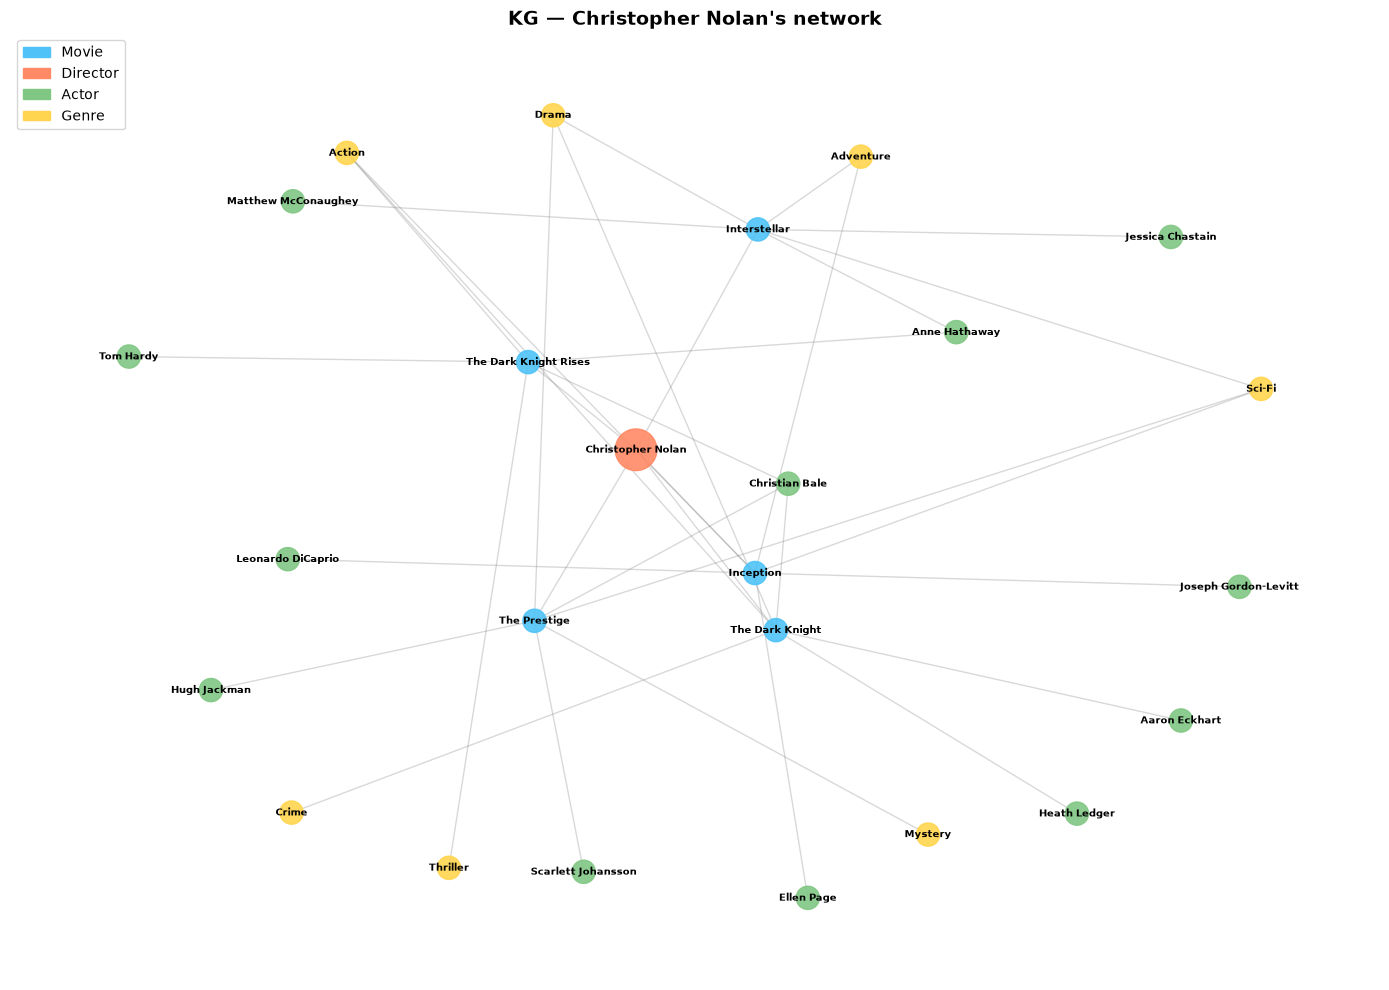

✅ Saved: kg_Christopher_Nolan.png


In [5]:
def visualize_subgraph(G: nx.Graph, center_node: str, depth: int = 2, title: str = ""):
    nodes = nx.single_source_shortest_path_length(G, center_node, cutoff=depth).keys()
    sg = G.subgraph(nodes)
    color_map = {'movie': '#4FC3F7', 'director': '#FF8A65', 'actor': '#81C784', 'genre': '#FFD54F'}
    node_colors = [color_map.get(sg.nodes[n].get('type', 'movie'), '#BDBDBD') for n in sg.nodes]
    node_sizes  = [900 if n == center_node else 280 for n in sg.nodes]

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(sg, seed=42, k=2)
    nx.draw_networkx_nodes(sg, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(sg, pos, alpha=0.3, edge_color='gray')
    nx.draw_networkx_labels(sg, pos, font_size=7, font_weight='bold')

    legend = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in color_map.items()]
    plt.legend(handles=legend, loc='upper left', fontsize=10)
    plt.title(title or f"KG: {center_node} (depth={depth})", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    fname = f"kg_{center_node.replace(' ', '_').replace('/', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {fname}")


directors = [n for n, d in G.nodes(data=True) if d.get('type') == 'director']
top_director = max(directors, key=lambda d: G.degree(d))
print(f"Most connected director: {top_director} ({G.degree(top_director)} connections)")
visualize_subgraph(G, top_director, depth=2, title=f"KG — {top_director}'s network")

Most connected genre: Drama (99 movies)


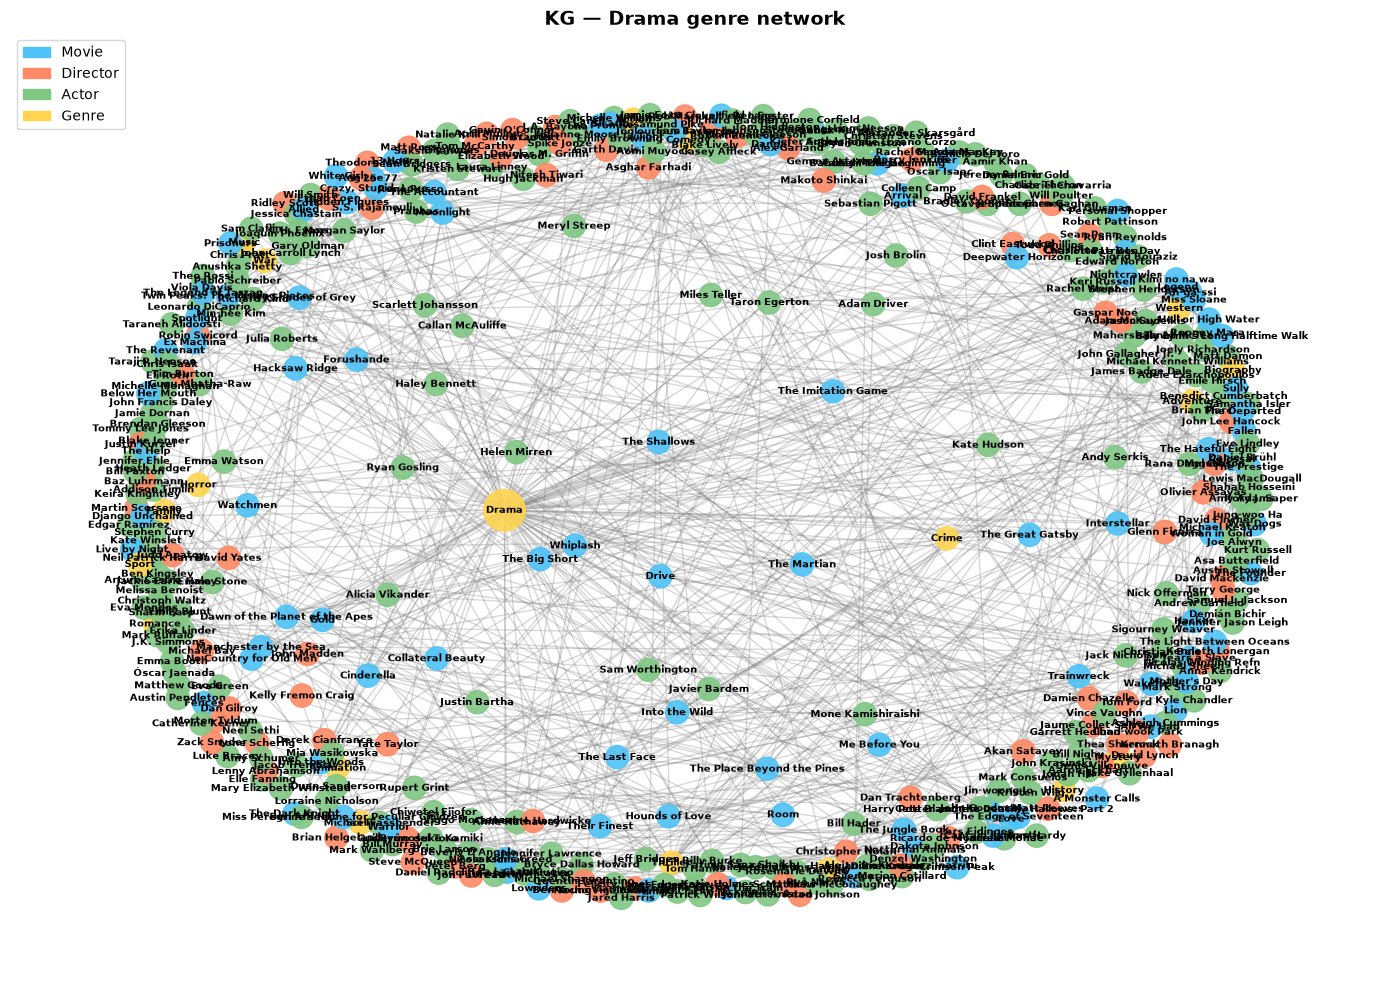

✅ Saved: kg_Drama.png


In [6]:
genres = [n for n, d in G.nodes(data=True) if d.get('type') == 'genre']
top_genre = max(genres, key=lambda g: G.degree(g))
print(f"Most connected genre: {top_genre} ({G.degree(top_genre)} movies)")
visualize_subgraph(G, top_genre, depth=2, title=f"KG — {top_genre} genre network")

---
## Phase 4: Custom Graph Query Tools

We define Python methods and pass them directly as tools to the Agno agent.  
Agno uses the **docstring** as the tool description and **type hints** to infer parameters.

In [7]:
import json


class MovieGraphTools:
    """Graph query tools the Agno agent can call."""

    def __init__(self, graph: nx.Graph):
        self.G = graph

    def get_node_info(self, node_name: str) -> str:
        """Get type and connections for a specific node in the knowledge graph."""
        if node_name not in self.G:
            return f"Node '{node_name}' not found. Try a movie title, director, actor, or genre name."
        data = self.G.nodes[node_name]
        neighbors = list(self.G.neighbors(node_name))
        by_type: dict = {}
        for n in neighbors:
            t = self.G.nodes[n].get('type', 'unknown')
            by_type.setdefault(t, []).append(n)
        return json.dumps({
            "node": node_name,
            "type": data.get('type'),
            "attributes": {k: v for k, v in data.items() if k != 'type'},
            "connections_by_type": by_type,
            "total_connections": len(neighbors),
        }, indent=2)

    def find_common_collaborators(self, entity1: str, entity2: str) -> str:
        """Find movies or people that both entities have in common.
        Use to answer: 'Do actor A and director B share any movies?'"""
        if entity1 not in self.G or entity2 not in self.G:
            return f"One or both entities not found: {entity1}, {entity2}"
        n1 = set(self.G.neighbors(entity1))
        n2 = set(self.G.neighbors(entity2))
        common = n1 & n2
        return json.dumps({
            "entity1": entity1, "entity2": entity2,
            "common_connections": sorted(list(common)),
            "common_count": len(common),
        }, indent=2)

    def find_connection_path(self, source: str, target: str) -> str:
        """Find the shortest path between two entities in the knowledge graph.
        Reveals indirect relationships — e.g. how two actors are connected through directors."""
        if source not in self.G or target not in self.G:
            return f"One or both entities not found: {source}, {target}"
        try:
            path = nx.shortest_path(self.G, source, target)
            path_with_types = [{"name": n, "type": self.G.nodes[n].get('type')} for n in path]
            return json.dumps({"path": path_with_types, "degrees_of_separation": len(path) - 1}, indent=2)
        except nx.NetworkXNoPath:
            return f"No path found between '{source}' and '{target}'"

    def get_top_nodes_by_centrality(self, node_type: str, metric: str = "degree", top_n: int = 10) -> str:
        """Get the most influential nodes by centrality metric.
        node_type: 'movie', 'director', 'actor', or 'genre'.
        metric: 'degree', 'betweenness', or 'closeness'."""
        if metric == "degree":
            scores = dict(nx.degree_centrality(self.G))
        elif metric == "betweenness":
            scores = nx.betweenness_centrality(self.G)
        else:
            scores = nx.closeness_centrality(self.G)
        filtered = {n: s for n, s in scores.items() if self.G.nodes[n].get('type') == node_type}
        top = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:top_n]
        return json.dumps({
            "metric": metric, "node_type": node_type,
            "top_nodes": [{'name': n, 'score': round(s, 4)} for n, s in top]
        }, indent=2)

    def detect_genre_bridges(self) -> str:
        """Find actors/directors who span the most different genres — they are 'genre bridges'."""
        bridges = []
        for node, data in self.G.nodes(data=True):
            if data.get('type') not in ('actor', 'director'):
                continue
            genres_reached: set = set()
            for movie in self.G.neighbors(node):
                if self.G.nodes[movie].get('type') == 'movie':
                    for g in self.G.neighbors(movie):
                        if self.G.nodes[g].get('type') == 'genre':
                            genres_reached.add(g)
            if len(genres_reached) >= 2:
                bridges.append({
                    'entity': node, 'type': data['type'],
                    'genres_bridged': sorted(list(genres_reached)),
                    'genre_count': len(genres_reached)
                })
        bridges.sort(key=lambda x: x['genre_count'], reverse=True)
        return json.dumps({"top_genre_bridges": bridges[:10]}, indent=2)

    def find_indirect_collaborations(self, director1: str, director2: str) -> str:
        """Find actors shared between two directors — a second-order query.
        Reveals indirect connections through shared cast members even if directors never co-directed."""
        if director1 not in self.G or director2 not in self.G:
            return f"Director(s) not found: {director1}, {director2}"

        def get_director_actors(director: str) -> set:
            actors: set = set()
            for movie in self.G.neighbors(director):
                if self.G.nodes[movie].get('type') == 'movie':
                    for person in self.G.neighbors(movie):
                        if self.G.nodes[person].get('type') == 'actor':
                            actors.add(person)
            return actors

        actors1 = get_director_actors(director1)
        actors2 = get_director_actors(director2)
        shared_actors = actors1 & actors2

        direct_movies = [
            n for n in self.G.neighbors(director1)
            if self.G.nodes[n].get('type') == 'movie' and self.G.has_edge(director2, n)
        ]

        return json.dumps({
            "director1": director1, "director2": director2,
            "directly_collaborated": len(direct_movies) > 0,
            "direct_movies": direct_movies,
            "shared_actors_indirectly": sorted(list(shared_actors)),
            "shared_actor_count": len(shared_actors),
        }, indent=2)


graph_tools = MovieGraphTools(G)
print("✅ Graph query tools ready")

✅ Graph query tools ready


---
## Phase 5: Agno Agent with Graph Tools

In [8]:
from agno.agent import Agent
from agno.models.openai import OpenAIChat

kg_agent = Agent(
    name="IMDB Knowledge Graph Agent",
    model=OpenAIChat(id="google/gemini-2.5-flash"),
    tools=[
        graph_tools.get_node_info,
        graph_tools.find_common_collaborators,
        graph_tools.find_connection_path,
        graph_tools.get_top_nodes_by_centrality,
        graph_tools.detect_genre_bridges,
        graph_tools.find_indirect_collaborations,
    ],
    instructions=[
        "You analyze a movie knowledge graph with 200 IMDB movies.",
        "Node types: Movie, Director, Actor, Genre. Edge types: directed, acted_in, genre_of.",
        "For first-order queries (direct facts) use get_node_info.",
        "For second-order queries (relationship-of-relationships) use centrality, bridges, and indirect collaborations.",
        "Always call a tool before answering — do not guess from training memory.",
        "Format answers clearly with markdown tables when listing multiple items.",
    ],
    
    markdown=True,
)

print("✅ Knowledge Graph Agent ready")

✅ Knowledge Graph Agent ready


### First-Order Queries — Direct lookups

In [9]:
kg_agent.print_response(
    "Who are the top 5 most influential directors ranked by degree centrality?",
    stream=True,
)

Output()

In [10]:
kg_agent.print_response(
    "Which genres have the most movies in the graph? Show the top 5.",
    stream=True,
)

Output()

### Second-Order Queries — Relationship reasoning

In [11]:
# Genre bridges: who spans the most genres?
kg_agent.print_response(
    "Identify actors or directors who serve as bridges between the most different genres. Show top 5.",
    stream=True,
)

Output()

In [12]:
# Indirect collaboration between the two most connected directors
directors_ranked = sorted(
    [(n, G.degree(n)) for n, d in G.nodes(data=True) if d.get('type') == 'director'],
    key=lambda x: x[1], reverse=True
)[:5]
print("Top directors:", [d[0] for d in directors_ranked])

dir1, dir2 = directors_ranked[0][0], directors_ranked[1][0]
kg_agent.print_response(
    f"Do '{dir1}' and '{dir2}' share any actors even if they never co-directed? "
    "Find their indirect connection through shared cast members.",
    stream=True,
)

Top directors: ['Christopher Nolan', 'Martin Scorsese', 'David Yates', 'Denis Villeneuve', 'Zack Snyder']


Output()

In [13]:
# Path analysis: degrees of separation
movies_list = [n for n, d in G.nodes(data=True) if d.get('type') == 'movie'][:5]
print("Sample movies:", movies_list)

kg_agent.print_response(
    f"Find the shortest connection path between '{movies_list[0]}' and '{movies_list[-1]}'. "
    "Explain each hop and what it represents.",
    stream=True,
)

Sample movies: ['Guardians of the Galaxy', 'Prometheus', 'Split', 'Sing', 'Suicide Squad']


Output()

In [14]:
# Betweenness centrality — influence propagation
kg_agent.print_response(
    "Which actors have the highest betweenness centrality? "
    "These are actors who most often bridge different parts of the network. "
    "Show top 5 and explain what this means.",
    stream=True,
)

Output()

---
## Phase 6: Agent-Built Knowledge Graph (Agno-native)

In [15]:
from agno.agent import Agent
from agno.models.openai import OpenAIChat
from agno.tools.csv_toolkit import CsvTools
from agno.tools.python import PythonTools

kg_builder_agent = Agent(
    name="IMDB KG Builder Agent",
    model=OpenAIChat(id="google/gemini-2.5-flash"),
    tools=[
        CsvTools(csvs=["imdb.csv"]),
        PythonTools(),
    ],
    instructions=[
        "You are an expert at analyzing movie data and building knowledge graphs.",
        "Use only the first 200 rows of the CSV.",
        "Always examine the CSV structure with CsvTools before writing any Python code.",
        "Build nodes for: Directors, Genres, Actors (first 2 per movie), Movies.",
        "Add edges with weights based on movie ratings.",
        "Use networkx for graph operations, matplotlib for visualization.",
        "Save all plots as PNG files.",
        "Run community detection using nx.community.greedy_modularity_communities.",
    ],
    markdown=True,
)

kg_builder_agent.print_response(
    """
    Using the IMDB CSV file (first 200 rows):

    1. Examine the CSV structure — columns and 3 sample rows
    2. Build a knowledge graph (Movie, Director, Actor, Genre nodes; edges weighted by rating)
    3. Print node/edge counts by type
    4. Visualize with color-coded node types — save as 'kg_overview.png'
    5. Run community detection — identify the 3 largest communities
    6. Visualize communities with different colors — save as 'kg_communities.png'
    7. List top 3 most influential actors and directors by degree centrality
    """,
    stream=True,
)

WARNING  `duckdb` not installed. Query functionality disabled.: No module named 'duckdb'

Output()

INFO Reading columns from file: imdb

INFO Reading file: imdb

WARNING  PythonTools can run arbitrary code, please provide human supervision.

...


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


INFO Reading file: imdb

ERROR    Error from OpenAI API: JSON error injected into SSE stream

ERROR    Error in Agent run: JSON error injected into SSE stream

---
## Summary

### Two Approaches

| Approach | When to use | Agno Primitives |
|----------|-------------|----------------|
| **Custom graph tools** | Pre-built graph, deterministic queries | Python methods → `Agent(tools=[...])` |
| **Agent-built graph** | Exploratory, agent writes its own code | `CsvTools` + `PythonTools` |

### Second-Order Query Types Demonstrated

| Query Type | Graph Operation | Tool |
|-----------|----------------|------|
| Degrees of separation | Shortest path | `find_connection_path` |
| Genre bridging | 2-hop genre traversal | `detect_genre_bridges` |
| Network influence | Betweenness centrality | `get_top_nodes_by_centrality(metric='betweenness')` |
| Community detection | Modularity clustering | `nx.community.*` via PythonTools |
| Indirect collaboration | Actor set intersection | `find_indirect_collaborations` |

👉 **Day 2** covers multi-agent patterns: Coordinator, Hierarchical, Swarm, Review-Critique, Human-in-Loop.